<img src="../files/misc/logo.gif" width=300/>
<h1 style="color:#872325">File I/O y Módulos</h1>

En esta sección veremos como trabajar y manipular archivos desde python. Python viene incluido con una serie de librerías y funciones predefinidas que nos permiten trabajar con archivos. De esta manera, al correr un proceso, podemos guardar su resultado a un archivo o, en su defecto, leer el contenido del archivo a fin de trabajar con sus valores.

### `open`

La función `open` nos permite abrir un archivo encontrado desde nuestra computadora. Con un archivo abierto, podemos escribir, leer, o añadir. 

**Es importante tener en cuenta en donde estamos trabajando y en donde se encuentra el archivo que queremos leer.**

Actualmente me encuentro en el directorio

In [4]:
pwd

'C:\\Users\\apgt\\Documents\\Trabajo\\Clases\\Analyisic\\Python 2022-05-09\\repo\\intro_python\\notes'

El archivo que deseamos leer se llama `texto.txt`, el cual no se encuentra dentro de la carpeta actual

In [5]:
ls

 Volume in drive C is Windows-SSD
 Volume Serial Number is 5456-27E3

 Directory of C:\Users\apgt\Documents\Trabajo\Clases\Analyisic\Python 2022-05-09\repo\intro_python\notes

25-May-22  08:39 PM    <DIR>          .
25-May-22  08:39 PM    <DIR>          ..
25-May-22  06:18 PM    <DIR>          .ipynb_checkpoints
16-May-22  06:05 PM            86,732 lec01.ipynb
16-May-22  08:44 PM            43,416 lec02.ipynb
18-May-22  08:36 PM            31,913 lec03.ipynb
23-May-22  07:52 PM            29,512 lec04.ipynb
25-May-22  08:30 PM            59,645 lec05.ipynb
25-May-22  08:39 PM           940,332 lec06.ipynb
               6 File(s)      1,191,550 bytes
               3 Dir(s)  275,621,126,144 bytes free


Sabiendo la ruta al archivo a leer, existen dos maneras de acceder directamente al archivo sin necesidad de modificar el directorio en donde estamos trabajando.

En este ejemplo, el archivo a leer se encuentra dentro de  
`C:\Users\apgt\Documents\Trabajo\Clases\Analyisic\Python 2022-05-09\repo\intro_python\files\lec06`

**Referencia Absoluta**  
La primera manera es llegar al archivo desedo considerando toda la ruta hasta el archivo a leer  
`C:\Users\apgt\Documents\Trabajo\Clases\Analyisic\Python 2022-05-09\repo\intro_python\files`

**Referencia Relativa**  
La segunda manera es especificando, relativo a nuestro directorio, hacía donde nos vamos a mover. Abajo se muestra el diagrama del proyecto.
```
.
├── README.md
├── files
│   ├── lec01
│   │   ├── hello.py
│   │   ├── hw_script.png
│   │   └── hw_terminal.png
│   ├── lec02
│   │   ├── prg01.png
│   │   └── prg02.png
│   ├── lec06
│   │   ├── mun_cdmx.csv
│   │   └── texto.txt
│   └── misc
│       └── logo.gif
└── notas
    ├── lec01.ipynb
    ├── lec02.ipynb
    ├── lec03.ipynb
    ├── lec04.ipynb
    ├── lec05.ipynb
    ├── lec06.ipynb
    └── lec07.ipynb
```


 Nos encontramos actualmente dentro la carpeta `notas`. Si quisieramos llegar a la carpeta `lec06` dentro de `files`, tendríamos que *retroceder* una carpeta para luego acceder a `files`.
 
 Retrocedemos una carpeta de manera *relativa* por medio de `..`. En otras palabras, si quisieramos acceder al archivo `texto.txt` de manera relativa, la ruta sería  
`../files/lec06/texto.txt`

### ...de regreso a `open` (leyendo archivos)

Abrimos y leemos un archivo en Python con la función `open` cuyo primer argumento es la ruta del archivo a a acceder.

```python
open(file, mode='r', buffering=-1, encoding=None, errors=None, newline=None, closefd=True, opener=None)
```

In [6]:
ruta_archivo = "../files/lec06/texto.txt"

f = open(ruta_archivo)
f

<_io.TextIOWrapper name='../files/lec06/texto.txt' mode='r' encoding='cp1252'>

In [7]:
type(f)

_io.TextIOWrapper

El resultado de abrir un archivo es un `file object` sobre el cual podemos manipular antes de visualizar el contenido del archivo. Dependiendo del *modo* seleccionado para trabajar con el archivo, `f` toma diferentes propiedades. Por *default* el modo es *r* (read), sin embargo, existen diferentes modos de trabajo. Enunciaremos los más comunes abajo.

* `r`: leer (default)
* `w`: escribir
* `a`: escribir. Agrega información al final del archivo si este ya existe
* `b`: binario. Para trabajar con archivos binarios, e.g., excel

In [8]:
# Leemos los contenidos del archivo
f.read()

'Esto es un archivo de texto.\n'

Para evitar posibles conflictos en el archivo, es importante cerrarlo una vez que se haya terminado de utilizar

In [9]:
f.close()

Una vez abierto un archivo es imprescindible cerrarlo. Para tener un poco más de legibilidad y no olvidar cerrar el archivo, se puede hacer uso del *keyword* `with` que abre un archivo dentro de un bloque de texto para posteiormente cerrarlo.

El keywork `with` toma un objeto (en nuestro caso un lector de archivos) que incluya dos métodos: `.open` y `.close`. Python se encarga de abrir y cerrar el archivo.


```python
with open(filename, mode) as f:
    <manipulación del archivo>
```

In [15]:
with open(ruta_archivo, "r") as my_file:
    print(my_file.readlines())
    # Cuando se termina el bloque python
    # cierra automaticamente el archivo

['0\n', '1\n', '2\n', '3\n', '4\n', '5\n', '6\n', '7\n', '8\n', '9\n']


Si tratamos de volver a leer el archivo, el siguiente error nos aparece:
```python
>>> f.read()
ValueError                                Traceback (most recent call last)
<ipython-input-24-873bb1270d85> in <module>()
      1 # Si tratamos y
----> 2 f.read()

ValueError: I/O operation on closed file.
```
El cuál anuncia que el archivo ha sido cerrado

### Escribiendo Archivos
El modo `"w"` dentro de `open` nos permite crear nuevos archivos. La sintáxis sería la siguiente
```python
open(filename, "w")
```

In [12]:
with open(ruta_archivo, "w") as my_file:
    for i in range(10):
        my_file.write(str(i) + "\n")

**Notas**  
* El código anterior escribió un caracter después de otro.
* Fue necesario convertir nuestro `int` a un `str` para poder escribir su valor

## Módulos

Un modulo  es un archivo escrito en python con funciones, clases, etc. Python contiene una librería *estándard* que contiene diferentes funciones o clases. Para hace uso de estas librerías, es necesario importarlas.

**Dos maneras de importar librerias en Python**
```python
import libreria
from libreria import modulo
```

La primera manera de cargar una libreria es importar el nombre de la libreria. Para poder acceder a un elemento de la libería de esta manera es necesario acceder a este como `libreria.elemento`

In [22]:
# Para poder recargar un modulo una vez que ya se habia importado
import importlib
importlib.reload(mi_modulo)

<module 'mi_modulo' from 'C:\\Users\\apgt\\Documents\\Trabajo\\Clases\\Analyisic\\Python 2022-05-09\\repo\\intro_python\\notes\\mi_modulo.py'>

In [24]:
import pandas

In [25]:
importlib.reload(pandas)

<module 'pandas' from 'C:\\Users\\apgt\\miniconda3\\envs\\cursos\\lib\\site-packages\\pandas\\__init__.py'>

In [19]:
import mi_modulo

In [17]:
mi_modulo.mi_variable

'hola mundo!'

In [26]:
mi_modulo.mi_funcion_de_ejemplo()

Este es un ejemplo


In [29]:
dir(mi_modulo)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'mi_funcion_de_ejemplo',
 'mi_variable']

Para poder ver los elementos que dependen de una libreria (o cualquier función) usamos la función `dir`.

In [27]:
import math

In [30]:
print(dir(math))

['__doc__', '__loader__', '__name__', '__package__', '__spec__', 'acos', 'acosh', 'asin', 'asinh', 'atan', 'atan2', 'atanh', 'ceil', 'comb', 'copysign', 'cos', 'cosh', 'degrees', 'dist', 'e', 'erf', 'erfc', 'exp', 'expm1', 'fabs', 'factorial', 'floor', 'fmod', 'frexp', 'fsum', 'gamma', 'gcd', 'hypot', 'inf', 'isclose', 'isfinite', 'isinf', 'isnan', 'isqrt', 'lcm', 'ldexp', 'lgamma', 'log', 'log10', 'log1p', 'log2', 'modf', 'nan', 'nextafter', 'perm', 'pi', 'pow', 'prod', 'radians', 'remainder', 'sin', 'sinh', 'sqrt', 'tan', 'tanh', 'tau', 'trunc', 'ulp']


Si deseamos solo un objecto de un módulo, podemos importar el objecto sin importar toda la librería usando 
```python
from modulo import objecto
```

In [34]:
# Tenemos que usar el prefijo
print(math.pi)
math.factorial(5)

3.141592653589793


120

In [32]:
from math import factorial

In [33]:
# Nos permite mandar a llamar la funcion sin utilizar la llave del modulo
factorial(5)

120

In [35]:
gamma(50)

NameError: name 'gamma' is not defined

In [36]:
math.gamma(50)

6.082818640342675e+62

## Módulos I/O

### JSON

JSON (Javascript Object Notation) es un formato de bajo peso para intercambio de información basado en el lenguaje de programación JavaScript. Es parecido, en estructura, a un diccionario.

Podemos cargar objectos json desde python con la librería `json`

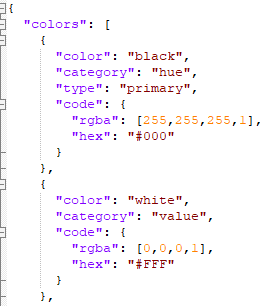

In [1]:
import json

Para cargar archivos json, es necesario abrir un archivo y usar la función `json.load` aplicado sobre el archivo abierto

In [2]:
with open("../files/lec07/colors.json") as f:
    colors = json.load(f)
print(colors)

{'colors': [{'color': 'black', 'category': 'hue', 'type': 'primary', 'code': {'rgba': [255, 255, 255, 1], 'hex': '#000'}}, {'color': 'white', 'category': 'value', 'code': {'rgba': [0, 0, 0, 1], 'hex': '#FFF'}}, {'color': 'red', 'category': 'hue', 'type': 'primary', 'code': {'rgba': [255, 0, 0, 1], 'hex': '#FF0'}}, {'color': 'blue', 'category': 'hue', 'type': 'primary', 'code': {'rgba': [0, 0, 255, 1], 'hex': '#00F'}}, {'color': 'yellow', 'category': 'hue', 'type': 'primary', 'code': {'rgba': [255, 255, 0, 1], 'hex': '#FF0'}}, {'color': 'green', 'category': 'hue', 'type': 'secondary', 'code': {'rgba': [0, 255, 0, 1], 'hex': '#0F0'}}]}


In [3]:
colors["colors"]

[{'color': 'black',
  'category': 'hue',
  'type': 'primary',
  'code': {'rgba': [255, 255, 255, 1], 'hex': '#000'}},
 {'color': 'white',
  'category': 'value',
  'code': {'rgba': [0, 0, 0, 1], 'hex': '#FFF'}},
 {'color': 'red',
  'category': 'hue',
  'type': 'primary',
  'code': {'rgba': [255, 0, 0, 1], 'hex': '#FF0'}},
 {'color': 'blue',
  'category': 'hue',
  'type': 'primary',
  'code': {'rgba': [0, 0, 255, 1], 'hex': '#00F'}},
 {'color': 'yellow',
  'category': 'hue',
  'type': 'primary',
  'code': {'rgba': [255, 255, 0, 1], 'hex': '#FF0'}},
 {'color': 'green',
  'category': 'hue',
  'type': 'secondary',
  'code': {'rgba': [0, 255, 0, 1], 'hex': '#0F0'}}]

In [4]:
colors["colors"][0]

{'color': 'black',
 'category': 'hue',
 'type': 'primary',
 'code': {'rgba': [255, 255, 255, 1], 'hex': '#000'}}

In [5]:
colors["colors"][0]["category"]

'hue'

In [6]:
type(colors)

dict

In [8]:
test_dict_output = {
    "acciones": {
        "AAPL": [149,145,156],
        "MSFT": {
            "Prices": [270,260,250],
            "Company": "Microsoft",
        }
    },
    "bonos": {
        "CETES": [9.9,9.81,9.84,9.63],
        "MBONO": [0.07,0.08,0.05,0.075]
    }
}

In [9]:
test_dict_output

{'acciones': {'AAPL': [149, 145, 156],
  'MSFT': {'Prices': [270, 260, 250], 'Company': 'Microsoft'}},
 'bonos': {'CETES': [9.9, 9.81, 9.84, 9.63],
  'MBONO': [0.07, 0.08, 0.05, 0.075]}}

In [10]:
output_file = open("financial_data.json", "w")
json.dump(test_dict_output, output_file)
output_file.close()

## CSV

In [11]:
import csv

In [24]:
# Primero abrir el archivo
lista_mun = []

with open("../files/lec07/mun_cdmx.csv") as f:
    datos_leidos = csv.DictReader(f)
    print('Field names:')
    print(datos_leidos.fieldnames)
    print('-----------------------------------------------------------------')

    for fila in datos_leidos:
        print(fila["CVE_MUN"],fila["NOM_MUN"])
        lista_mun.append(fila["NOM_MUN"])

print("\n",lista_mun)

Field names:
['CVE_ENT', 'NOM_ENT', 'CVE_MUN', 'NOM_MUN', 'CVE_CAB']
-----------------------------------------------------------------
2 Azcapotzalco
3 Coyoacan
4 Cuajimalpa de Morelos
5 Gustavo A. Madero
6 Iztacalco
7 Iztapalapa
8 La Magdalena Contreras
9 Milpa Alta
10 Alvaro Obregon
11 Tlahuac
12 Tlalpan
13 Xochimilco
14 Benito Juarez
15 Cuauhtemoc
16 Miguel Hidalgo
17 Venustiano Carranza

 ['Azcapotzalco', 'Coyoacan', 'Cuajimalpa de Morelos', 'Gustavo A. Madero', 'Iztacalco', 'Iztapalapa', 'La Magdalena Contreras', 'Milpa Alta', 'Alvaro Obregon', 'Tlahuac', 'Tlalpan', 'Xochimilco', 'Benito Juarez', 'Cuauhtemoc', 'Miguel Hidalgo', 'Venustiano Carranza']


In [25]:
# Escribir en un archivo csv numeros al cuadrado
with open("numeros.csv", "w") as f:
    csv_file = csv.DictWriter(f, ["num", "num^2"])
    csv_file.writeheader()
    for i in range(10):
        csv_file.writerow(
            {
                "num": i,
                "num^2": i**2,
            }
        )

## Datetime 

In [28]:
from datetime import datetime

Dando formato a las fechas. Documentación en:

https://docs.python.org/3/library/datetime.html?highlight=datetime#strftime-and-strptime-behavior

In [29]:
start_date = datetime(2022, 5, 30)

In [31]:
type(start_date)

datetime.datetime

In [32]:
print(start_date)

2022-05-30 00:00:00


In [33]:
start_date.weekday()

0

In [34]:
start_date.year

2022

In [35]:
start_date.month

5

In [36]:
start_date.day

30

In [44]:
# Escribir el objeto datetime en un formato especifico de fecha
print(start_date.strftime("%m %d %Y"))
print(start_date.strftime("%m/%d/%Y"))
print(start_date.strftime("%d-%m-%y"))
print("\nISO 8601:")
print(start_date.strftime("%Y-%m-%d"))

05 30 2022
05/30/2022
30-05-22

ISO 8601:
2022-05-30


In [45]:
from datetime import timedelta

In [46]:
tdelta = timedelta(days=30)
tdelta

datetime.timedelta(days=30)

In [49]:
maturity = start_date + tdelta
maturity

datetime.datetime(2022, 6, 29, 0, 0)

In [50]:
str_fecha = "2022.12.25"
datetime.strptime(str_fecha, "%Y.%m.%d")

datetime.datetime(2022, 12, 25, 0, 0)

<h3 style="color:crimson"> Ejercicio </h3>

1. Crea la función `timestep(init_date, n)` tal que, dada una fecha inicial y $n$ días de duración, calcule la fecha hábil final corriendo la fecha un día después al final de $n$ días si  cae en una fecha inhábil o en fin de semana. Para lograr esto, lee el archivo `../files/lec07/holidays.txt`

Considera cualquier fecha entre 1/1/10 y 12/25/50.

```python
>>> timestep(datetime(2009, 12, 31), 1)
datetime.datetime(2010, 1, 4, 0, 0)

>>> timestep(datetime(2009, 12, 31), 2)
datetime.datetime(2010, 1, 4, 0, 0)

>>> timestep(datetime(2017, 12, 26), 4)
datetime.datetime(2018, 1, 2, 0, 0)

>>> timestep(datetime(2018, 2, 19), 2)
datetime.datetime(2018, 2, 21, 0, 0)
```

2. Usando el archivo `6m_rates.csv`, crear el diccionario `tasas` donde las llaves sean las fechas (`datetime.datetime`) y los valores (`float`) las tasas a esa fecha.
```python
>>>tasas[datetime(2017, 2, 1)]
2.58
>>>tasas[datetime(2013, 4, 1)]
1.9
```

3. Crear una función `tasa_compuesta` que, para una tasa nominal fija compuesta $n$ veces en un año, calcule el valor del nominal para cada periodo $k = 0,\ldots, n$. 
```python
def tasa_compuesta(inicio_periodo, nominal, tasa_nominal, n_periodos, path="."):
    pass
```
La función debe regresar un archivo `.csv` de nombre `cap_n.csv`; donde `n` es el número de veces de capitalización en un año.

In [101]:
# Ejercicio 1

# 1. Cargar el archivo holidays
holidays_mex = []
with open("C:/Users/apgt/Documents/Trabajo/Clases/Analyisic/Python 2022-05-09/repo/intro_python/files/lec07/holidays.txt") as f:
    for line in f:
        fecha = datetime.strptime(line.replace("\n",""), "%m/%d/%y")
        holidays_mex.append(fecha)

# 2. Definir nuestra funcion
def timestep(init_date, n, holidays=[]):
    # 2.1 Desplazarnos n dias
    n_dias = timedelta(days=n)
    final_date = init_date + n_dias
    
    # 2.2a Si es habil regresar el dia desplazado
    # 2.2b Si es inhabil desplazarnos hasta el siguiente dia habil
    while (final_date.weekday() == 5 or final_date.weekday() == 6
            or final_date in holidays_mex):
        final_date = final_date + timedelta(days=1)
    
    return final_date

In [102]:
test_date = datetime(2009, 12, 31)
test_date

datetime.datetime(2009, 12, 31, 0, 0)

In [105]:
int(test_date.strftime("%Y%m%d"))

20091231

In [103]:
timestep(test_date, 1, holidays_mex)

datetime.datetime(2010, 1, 4, 0, 0)

## OS

In [106]:
import os

In [107]:
# Current Working Directory
os.getcwd()

'C:\\Users\\apgt\\Documents\\Trabajo\\Clases\\Analyisic\\Python 2022-05-09\\repo\\intro_python\\notes'

In [108]:
# Crear una nueva carpeta
parent = "C:/Prueba_Python/"
nueva_carpeta = "Clase_06"

path = os.path.join(parent, nueva_carpeta)

os.mkdir(path)

In [109]:
# Listar todos los elementos dentro de la carpeta
os.listdir(".") # . corresponde al directorio de trabajo

['.ipynb_checkpoints',
 'financial_data.json',
 'lec01.ipynb',
 'lec02.ipynb',
 'lec03.ipynb',
 'lec04.ipynb',
 'lec05.ipynb',
 'lec06.ipynb',
 'lec07.ipynb',
 'mi_modulo.py',
 'numeros.csv',
 'pandas.ipynb',
 '__pycache__']

In [110]:
os.listdir("../")

['.git', '.gitignore', 'docs', 'files', 'notes', 'tareas']

In [112]:
for path_directory, folder_names, file_names in os.walk("../"):
    print(path_directory)
    print('Carpetas:', folder_names)
    print('Archivos:', file_names)

../
Carpetas: ['.git', 'docs', 'files', 'notes', 'tareas']
Archivos: ['.gitignore']
../.git
Carpetas: ['hooks', 'info', 'logs', 'objects', 'refs']
Archivos: ['COMMIT_EDITMSG', 'config', 'description', 'HEAD', 'index']
../.git\hooks
Carpetas: []
Archivos: ['applypatch-msg.sample', 'commit-msg.sample', 'fsmonitor-watchman.sample', 'post-update.sample', 'pre-applypatch.sample', 'pre-commit.sample', 'pre-merge-commit.sample', 'pre-push.sample', 'pre-rebase.sample', 'pre-receive.sample', 'prepare-commit-msg.sample', 'push-to-checkout.sample', 'update.sample']
../.git\info
Carpetas: []
Archivos: ['exclude']
../.git\logs
Carpetas: ['refs']
Archivos: ['HEAD']
../.git\logs\refs
Carpetas: ['heads', 'remotes']
Archivos: []
../.git\logs\refs\heads
Carpetas: []
Archivos: ['main']
../.git\logs\refs\remotes
Carpetas: ['origin']
Archivos: []
../.git\logs\refs\remotes\origin
Carpetas: []
Archivos: ['main']
../.git\objects
Carpetas: ['05', '06', '09', '16', '1d', '20', '29', '2a', '2c', '2d', '2e', '30'

## Regex ##

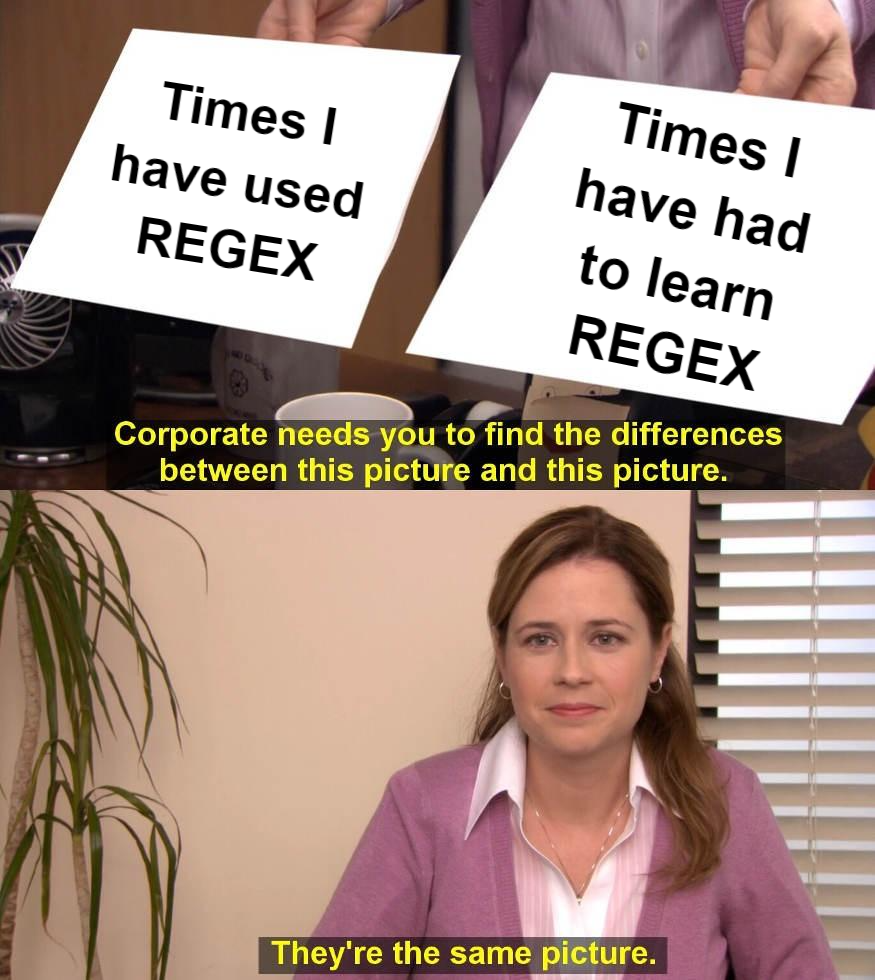